# Statistics analysis

This notebook averages repeated executions only when all recorded grid-search parameters match. It then compares the best averaged configuration for each implementation and dataset type, and keeps the scaling comparison separate from the grid-search comparison.

In [179]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

CSV_PATTERN = "hashjoin_*.csv"
RESULTS_CANDIDATES = [Path("results"), Path("src/results"), Path("../results")]
OLD_RESULTS_CANDIDATES = [Path("old_results"), Path("src/old_results"), Path("../old_results")]

GRID_TO_RESULT_COLUMNS = {
    "N_VALUES": ["nr", "ns"],
    "P_VALUES": ["p", "num_partitions", "partition_count"],
    "SEED_VALUES": ["seed"],
    "MAX_KEY_VALUES": ["max_key"],
    "DATASET_TYPE_VALUES": ["dataset_type"],
    "PARTITION_THREAD_VALUES": ["partition_threads"],
    "JOIN_THREAD_VALUES": ["join_threads"],
    "PARTITION_SCHEDULE_VALUES": ["partition_schedule"],
    "JOIN_SCHEDULE_VALUES": ["join_schedule"],
    "PARTITION_CHUNK_VALUES": ["partition_chunk"],
    "JOIN_CHUNK_VALUES": ["join_chunk"],
    "PARTITION_BLOCK_SIZE_VALUES": ["partition_block_size"],
    "PARTITION_TASK_GRAIN_VALUES": ["partition_task_grain"],
    "JOIN_TASK_GRAIN_VALUES": ["join_task_grain"],
    "OFFSET_TASK_GRAIN_VALUES": ["offset_task_grain"],
}

NUMERIC_COLUMNS = [
    "checksum1", "checksum2", "join_count", "join_threads", "join_throughput",
    "join_time", "max_key", "nr", "ns", "p", "num_partitions",
    "partition_threads", "partition_throughput", "partition_time", "time_sec",
    "tot_sec", "total_throughput", "partition_chunk", "join_chunk",
    "partition_block_size", "partition_task_grain", "join_task_grain",
    "offset_task_grain", "skew_fraction", "skew_partition_fraction", "seed",
]

EXEC_TYPE_ORDER = ["seq", "omp_loop", "omp_loop_wb","omp_task", "omp_task_wb", "omp_taskloop", "omp_taskloop_wb"]


def first_existing_dir(candidates):
    for candidate in candidates:
        if candidate.exists():
            return candidate
    return None


def find_csv_files(candidates, pattern):
    for candidate_dir in candidates:
        candidate_files = sorted(candidate_dir.glob(pattern))
        if candidate_files:
            return candidate_dir, candidate_files
    return None, []


def normalize_frame(frame):
    frame = frame.copy()
    if "tot_sec" not in frame.columns and "time_sec" in frame.columns:
        frame["tot_sec"] = frame["time_sec"]
    if "time_sec" not in frame.columns and "tot_sec" in frame.columns:
        frame["time_sec"] = frame["tot_sec"]
    if "dataset_type" not in frame.columns:
        frame["dataset_type"] = "uniform"

    for col in NUMERIC_COLUMNS:
        if col in frame.columns:
            frame[col] = pd.to_numeric(frame[col], errors="coerce")

    if {"nr", "ns", "tot_sec"}.issubset(frame.columns):
        fallback_total_throughput = (frame["nr"] + frame["ns"]) / frame["tot_sec"].where(frame["tot_sec"] > 0)
        if "total_throughput" not in frame.columns:
            frame["total_throughput"] = fallback_total_throughput
        else:
            frame["total_throughput"] = frame["total_throughput"].fillna(fallback_total_throughput)

    return frame


RESULTS_DIR, csv_files = find_csv_files(RESULTS_CANDIDATES, CSV_PATTERN)
if not csv_files or RESULTS_DIR is None:
    searched = ", ".join(str(p) for p in RESULTS_CANDIDATES)
    raise FileNotFoundError(f"No CSV files found with pattern {CSV_PATTERN} in: {searched}")

frames = []
for csv_path in csv_files:
    current_df = pd.read_csv(csv_path)
    current_df["exec_type"] = csv_path.stem.replace("hashjoin_", "", 1)
    frames.append(normalize_frame(current_df))

df = pd.concat(frames, ignore_index=True, sort=False)

exec_type_names = sorted(df["exec_type"].dropna().unique(), key=lambda x: (EXEC_TYPE_ORDER.index(x) if x in EXEC_TYPE_ORDER else len(EXEC_TYPE_ORDER), x))
exec_type_palette = ["#1533AA", "#2692B3", "#1BB86F", "#DFE223", "#F09C1E", "#D32C1D", "#E03CC7"]
color_map = {exec_type: exec_type_palette[idx % len(exec_type_palette)] for idx, exec_type in enumerate(exec_type_names)}


def apply_tone(base_color, tone_strength):
    strength = float(max(0.0, min(1.0, tone_strength)))
    base_rgb = mcolors.to_rgb(base_color)
    toned_rgb = tuple(1.0 - strength * (1.0 - channel) for channel in base_rgb)
    return mcolors.to_hex(toned_rgb)


def build_tone_strength_map(values, min_strength=0.45, max_strength=1.0):
    ordered = sorted(values)
    if not ordered:
        return {}
    if len(ordered) == 1:
        return {ordered[0]: float(max_strength)}
    span = float(max_strength) - float(min_strength)
    return {value: float(min_strength) + span * idx / (len(ordered) - 1) for idx, value in enumerate(ordered)}


def ordered_values(values, preferred=None):
    clean = [value for value in pd.Series(values).dropna().unique()]
    if preferred is None:
        return sorted(clean)
    return sorted(clean, key=lambda x: (preferred.index(x) if x in preferred else len(preferred), str(x)))


def fmt_num(value):
    if pd.isna(value):
        return "NA"
    value_float = float(value)
    return str(int(value_float)) if value_float.is_integer() else f"{value_float:g}"


def problem_label(row_or_tuple):
    if isinstance(row_or_tuple, tuple):
        nr, ns, max_key = row_or_tuple
    else:
        nr, ns, max_key = row_or_tuple["nr"], row_or_tuple["ns"], row_or_tuple["max_key"]
    return f"nr={fmt_num(nr)}, ns={fmt_num(ns)}, max_key={fmt_num(max_key)}"


def resolve_img_dir():
    candidates = [Path("src/img"), Path("img"), Path("../src/img"), Path("../img")]
    for candidate in candidates:
        if candidate.parent.exists() or candidate.exists():
            candidate.mkdir(parents=True, exist_ok=True)
            return candidate
    fallback = Path("img")
    fallback.mkdir(parents=True, exist_ok=True)
    return fallback


IMG_DIR = resolve_img_dir()
PLOT_SAVE_COUNTER = 0


def slugify(value):
    cleaned = re.sub(r"[^A-Za-z0-9._-]+", "_", str(value)).strip("_")
    return (cleaned or "plot")[:180]


def save_figure(fig, name_prefix):
    global PLOT_SAVE_COUNTER
    PLOT_SAVE_COUNTER += 1
    filename = f"{PLOT_SAVE_COUNTER:03d}_{slugify(name_prefix)}.png"
    output_path = IMG_DIR / filename
    fig.savefig(output_path, dpi=180, bbox_inches="tight")
    print(f"[saved] {output_path}")


def show_and_save(fig, name_prefix):
    save_figure(fig, name_prefix)
    plt.show()
    plt.close(fig)


print(f"[Loaded {df.shape[0]} runs from {RESULTS_DIR}]\n")
print("Files:")
for csv_path in csv_files:
    print(f"  - {csv_path.name}")
print("\nDistinct values:")
print(f"  exec_type: {exec_type_names}")
print(f"  dataset_type: {ordered_values(df['dataset_type'])}")
print(f"  max_key: {ordered_values(df['max_key'])}")
print(f"  partition_threads: {ordered_values(df['partition_threads']) if 'partition_threads' in df.columns else []}")
print(f"  join_threads: {ordered_values(df['join_threads']) if 'join_threads' in df.columns else []}")
print(f"  image_output_dir: {IMG_DIR}")


[Loaded 615 runs from results]

Files:
  - hashjoin_omp_loop.csv
  - hashjoin_omp_loop_wb.csv
  - hashjoin_omp_task.csv
  - hashjoin_omp_task_wb.csv
  - hashjoin_omp_taskloop.csv
  - hashjoin_omp_taskloop_wb.csv
  - hashjoin_seq.csv

Distinct values:
  exec_type: ['seq', 'omp_loop', 'omp_loop_wb', 'omp_task', 'omp_task_wb', 'omp_taskloop', 'omp_taskloop_wb']
  dataset_type: ['skewed_90_1', 'skewed_90_5', 'uniform']
  max_key: [1000000]
  partition_threads: [1, 32, 64]
  join_threads: [1, 32]
  image_output_dir: img


# Checksum validation

In [180]:
checksum_group_cols = [col for col in ["nr", "ns", "max_key", "dataset_type"] if col in df.columns]
summary_rows = []

for key_values, subdf in df.groupby(checksum_group_cols, dropna=False):
    if not isinstance(key_values, tuple):
        key_values = (key_values,)
    row = dict(zip(checksum_group_cols, key_values))
    checksum_pairs = subdf[["checksum1", "checksum2"]].drop_duplicates() if {"checksum1", "checksum2"}.issubset(subdf.columns) else pd.DataFrame()
    row.update({
        "n_distinct_checksum_pairs": len(checksum_pairs),
        "is_valid": len(checksum_pairs) == 1,
        "exec_types": ", ".join(ordered_values(subdf["exec_type"], EXEC_TYPE_ORDER)),
    })
    summary_rows.append(row)

checksum_validation_df = pd.DataFrame(summary_rows).sort_values(checksum_group_cols).reset_index(drop=True)
valid_groups = int(checksum_validation_df["is_valid"].sum()) if not checksum_validation_df.empty else 0
print(f"[OK groups: {valid_groups}/{len(checksum_validation_df)}]")
checksum_validation_df


[OK groups: 1/3]


,nr,ns,max_key,dataset_type,n_distinct_checksum_pairs,is_valid,exec_types
0,50000000,50000000,1000000,skewed_90_1,2,False,"seq, omp_loop, omp_loop_wb, omp_task, omp_task..."
1,50000000,50000000,1000000,skewed_90_5,2,False,"seq, omp_loop, omp_loop_wb, omp_task, omp_task..."
2,50000000,50000000,1000000,uniform,1,True,"seq, omp_loop, omp_loop_wb, omp_task, omp_task..."


# Average by Grid Parameters

In [181]:
recorded_grid_columns = []
missing_grid_parameters = []
for grid_name, candidate_columns in GRID_TO_RESULT_COLUMNS.items():
    present_columns = [col for col in candidate_columns if col in df.columns]
    if present_columns:
        for col in present_columns:
            if col not in recorded_grid_columns:
                recorded_grid_columns.append(col)
    else:
        missing_grid_parameters.append(grid_name)

avg_group_columns = ["exec_type"] + [col for col in recorded_grid_columns if col != "exec_type"]
avg_group_columns = [col for col in avg_group_columns if col in df.columns]

avg_columns = [
    col for col in df.columns
    if col not in avg_group_columns and pd.api.types.is_numeric_dtype(df[col])
]

stable_avg_df = (
    df.groupby(avg_group_columns, as_index=False, dropna=False)
    .agg(**{col: (col, "mean") for col in avg_columns}, n_runs=("tot_sec", "size"))
    .sort_values(avg_group_columns)
    .reset_index(drop=True)
)

print(f"recorded_grid_columns={recorded_grid_columns}")
if missing_grid_parameters:
    print(f"[warning] grid parameters absent from CSV and not usable as average keys: {missing_grid_parameters}")
print(f"non_averaged={df.shape}")
print(f"averaged={stable_avg_df.shape}")
display(stable_avg_df.head(10))


recorded_grid_columns=['nr', 'ns', 'max_key', 'dataset_type', 'partition_threads', 'join_threads', 'partition_schedule', 'join_schedule', 'partition_chunk', 'join_chunk', 'partition_block_size', 'partition_task_grain', 'join_task_grain', 'offset_task_grain']
[warning] grid parameters absent from CSV and not usable as average keys: ['P_VALUES', 'SEED_VALUES']
non_averaged=(615, 31)
averaged=(123, 31)


,exec_type,nr,ns,max_key,dataset_type,partition_threads,join_threads,partition_schedule,join_schedule,partition_chunk,...,partition_time,time_sec,total_throughput,tot_sec,join_task_partitions,offset_task_partitions,partition_task_blocks,skew_fraction,skew_partition_fraction,n_runs
0,omp_loop,50000000,50000000,1000000,skewed_90_1,32,32,guided,guided,0,...,0.332039,2.568697,3.893087e+07,2.568697,NaN,NaN,NaN,NaN,NaN,5
1,omp_loop,50000000,50000000,1000000,skewed_90_1,32,32,guided,guided,0,...,0.333196,2.576284,3.881685e+07,2.576284,NaN,NaN,NaN,NaN,NaN,5
2,omp_loop,50000000,50000000,1000000,skewed_90_1,32,32,guided,guided,8,...,0.332386,2.572905,3.886807e+07,2.572905,NaN,NaN,NaN,NaN,NaN,5
3,omp_loop,50000000,50000000,1000000,skewed_90_1,32,32,guided,guided,8,...,0.333574,2.583668,3.870559e+07,2.583668,NaN,NaN,NaN,NaN,NaN,5
4,omp_loop,50000000,50000000,1000000,skewed_90_5,32,32,guided,guided,0,...,0.351470,1.339456,7.473275e+07,1.339456,NaN,NaN,NaN,NaN,NaN,5
5,omp_loop,50000000,50000000,1000000,skewed_90_5,32,32,guided,guided,0,...,0.353754,1.325910,7.546244e+07,1.325910,NaN,NaN,NaN,NaN,NaN,5
6,omp_loop,50000000,50000000,1000000,skewed_90_5,32,32,guided,guided,8,...,0.354608,1.326387,7.540625e+07,1.326387,NaN,NaN,NaN,NaN,NaN,5
7,omp_loop,50000000,50000000,1000000,skewed_90_5,32,32,guided,guided,8,...,0.353761,1.329395,7.523097e+07,1.329395,NaN,NaN,NaN,NaN,NaN,5
8,omp_loop,50000000,50000000,1000000,uniform,32,32,guided,guided,0,...,0.363162,0.572916,1.745510e+08,0.572916,NaN,NaN,NaN,NaN,NaN,5
9,omp_loop,50000000,50000000,1000000,uniform,32,32,guided,guided,0,...,0.362133,0.572755,1.745998e+08,0.572755,NaN,NaN,NaN,NaN,NaN,5


# Best Averaged Records

In [182]:
problem_columns = [col for col in ["nr", "ns", "max_key"] if col in stable_avg_df.columns]
best_group_columns = problem_columns + ["dataset_type", "exec_type"]

eligible = stable_avg_df.dropna(subset=["tot_sec"]).copy()
if eligible.empty:
    raise ValueError("No averaged rows with tot_sec available")

best_indices = eligible.groupby(best_group_columns, dropna=False)["tot_sec"].idxmin()
selected_best_df = (
    eligible.loc[best_indices]
    .sort_values(best_group_columns)
    .reset_index(drop=True)
)

best_config_columns = [
    col for col in best_group_columns + [
        "n_runs", "tot_sec", "partition_time", "join_time", "total_throughput",
        "partition_threads", "join_threads", "partition_schedule", "join_schedule",
        "partition_chunk", "join_chunk", "partition_block_size",
        "partition_task_grain", "join_task_grain", "offset_task_grain",
    ]
    if col in selected_best_df.columns
]

print(f"selected_best_records={selected_best_df.shape}")
selected_best_df[best_config_columns]


selected_best_records=(21, 31)


,nr,ns,max_key,dataset_type,exec_type,n_runs,tot_sec,partition_time,join_time,total_throughput,partition_threads,join_threads,partition_schedule,join_schedule,partition_chunk,join_chunk,partition_block_size,partition_task_grain,join_task_grain,offset_task_grain
0,50000000,50000000,1000000,skewed_90_1,omp_loop,5,2.568697,0.332039,2.233499,3.893087e+07,32,32,guided,guided,0,0,32768,NaN,NaN,NaN
1,50000000,50000000,1000000,skewed_90_1,omp_loop_wb,5,1.144167,0.333365,0.807576,8.743047e+07,32,32,guided,guided,0,8,32768,NaN,NaN,NaN
2,50000000,50000000,1000000,skewed_90_1,omp_task,5,2.563019,0.320076,2.239744,3.901793e+07,64,32,auto,auto,0,0,32768,4.0,8.0,2.0
3,50000000,50000000,1000000,skewed_90_1,omp_task_wb,5,2.561850,0.321107,2.237352,3.903584e+07,64,32,auto,auto,0,0,32768,2.0,8.0,2.0
4,50000000,50000000,1000000,skewed_90_1,omp_taskloop,5,2.565969,0.326405,2.236362,3.897284e+07,64,32,auto,auto,0,0,32768,4.0,4.0,4.0
5,50000000,50000000,1000000,skewed_90_1,omp_taskloop_wb,5,1.117984,0.318516,0.796259,8.946668e+07,64,32,auto,auto,0,0,32768,2.0,4.0,4.0
6,50000000,50000000,1000000,skewed_90_1,seq,5,3.455040,1.977938,1.474730,2.895121e+07,1,1,static,static,0,0,32768,1.0,1.0,1.0
7,50000000,50000000,1000000,skewed_90_5,omp_loop,5,1.325910,0.353754,0.969019,7.546244e+07,32,32,guided,guided,0,8,32768,NaN,NaN,NaN
8,50000000,50000000,1000000,skewed_90_5,omp_loop_wb,5,0.542302,0.354974,0.184001,1.847429e+08,32,32,guided,guided,8,8,32768,NaN,NaN,NaN
9,50000000,50000000,1000000,skewed_90_5,omp_task,5,0.861789,0.334793,0.523728,1.160622e+08,64,32,auto,auto,0,0,32768,4.0,4.0,4.0


# Selected-Record Comparisons

[saved] img/001_selected_best_tot_sec_50000000_50000000_1000000.png


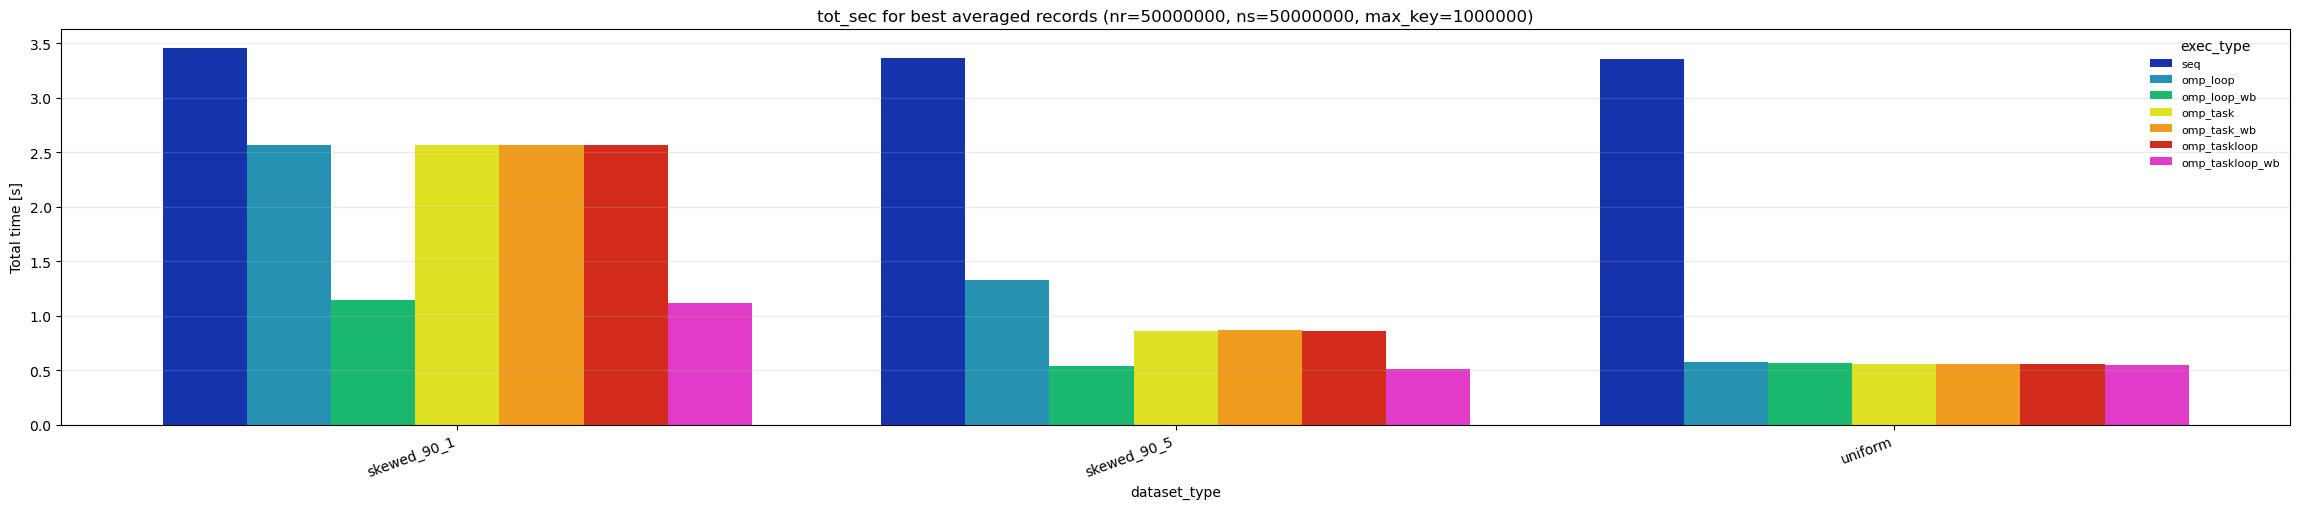

[saved] img/002_selected_best_partition_time_50000000_50000000_1000000.png


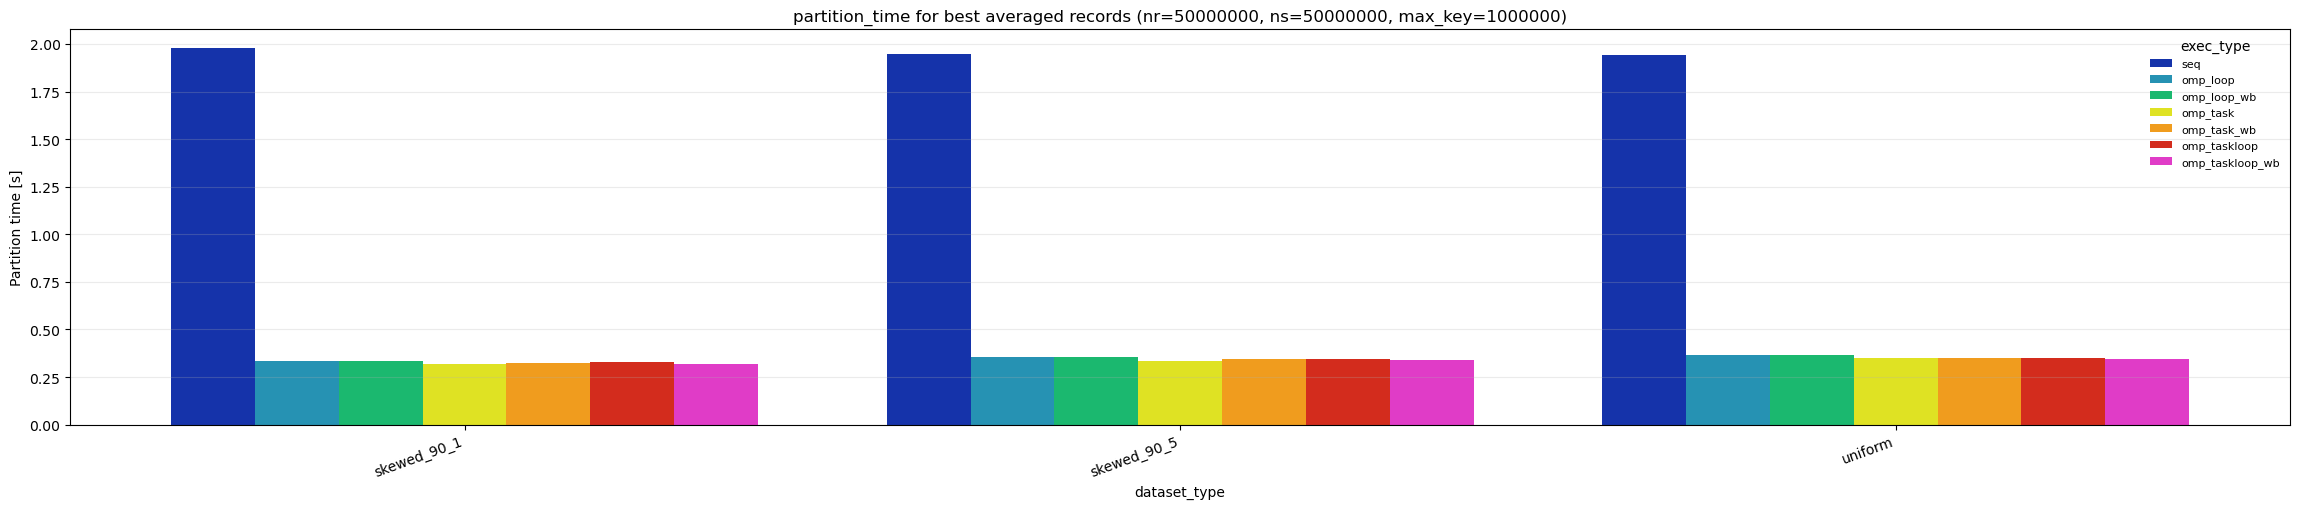

[saved] img/003_selected_best_join_time_50000000_50000000_1000000.png


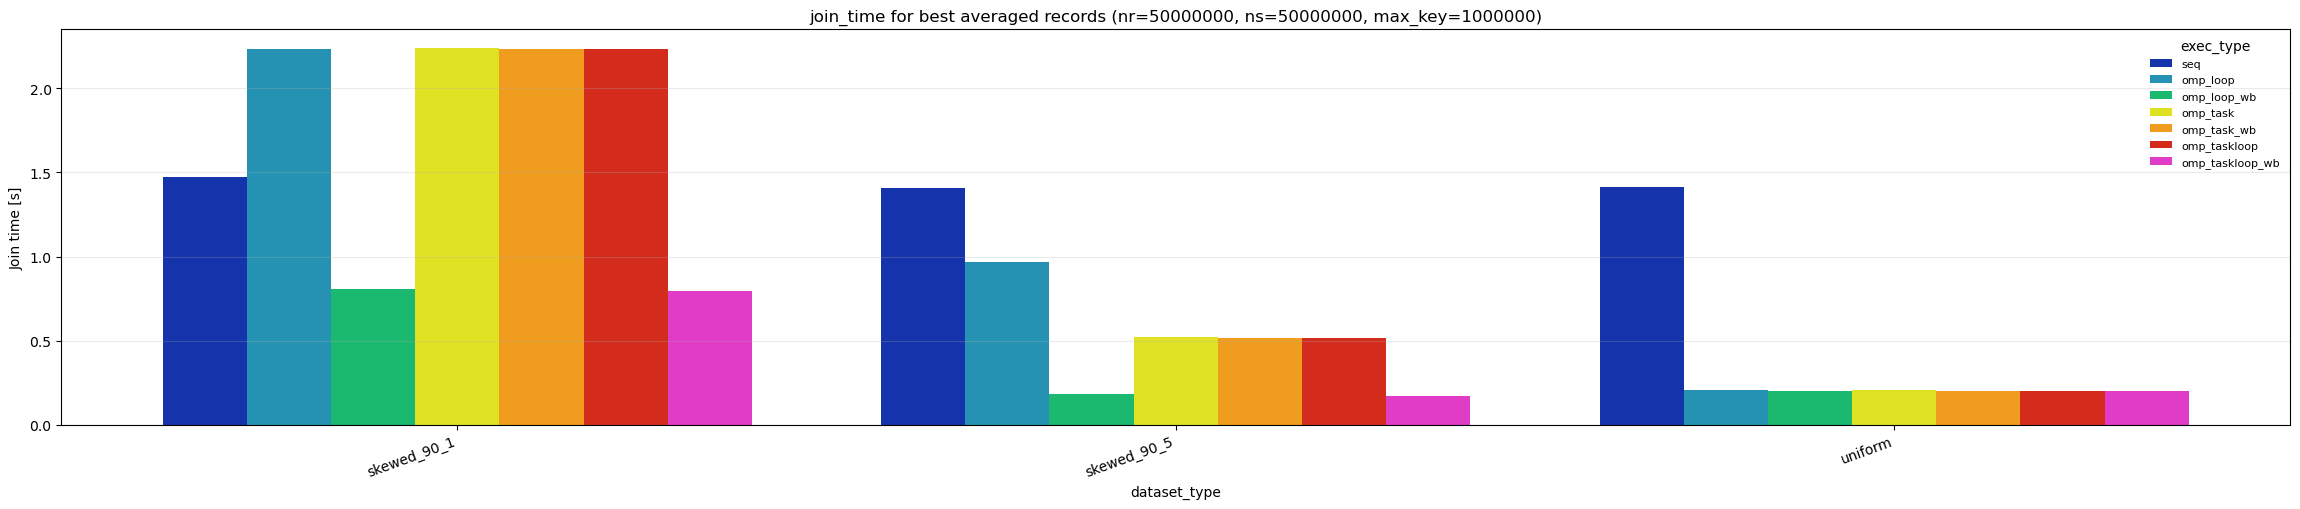

In [183]:
def plot_selected_metric(metric_df, metric_col, ylabel, title_prefix, hline=None):
    required = set(problem_columns + ["dataset_type", "exec_type", metric_col])
    missing = sorted(required - set(metric_df.columns))
    if missing:
        print(f"Skipping {metric_col}: missing columns {missing}")
        return

    plot_df = metric_df.dropna(subset=[metric_col]).copy()
    if plot_df.empty:
        print(f"Skipping {metric_col}: no valid values")
        return

    for problem_key, subdf in plot_df.groupby(problem_columns, dropna=False):
        if not isinstance(problem_key, tuple):
            problem_key = (problem_key,)
        dataset_types = ordered_values(subdf["dataset_type"])
        exec_types = ordered_values(subdf["exec_type"], EXEC_TYPE_ORDER)
        if not dataset_types or not exec_types:
            continue

        x_positions = np.arange(len(dataset_types))
        bar_width = 0.82 / max(len(exec_types), 1)
        fig, ax = plt.subplots(figsize=(max(8.8, 1.1 * len(dataset_types) * len(exec_types)), 5.2))

        for idx, exec_type in enumerate(exec_types):
            sub = subdf[subdf["exec_type"] == exec_type].set_index("dataset_type")[metric_col].to_dict()
            heights = [float(sub.get(dataset_type, np.nan)) for dataset_type in dataset_types]
            offsets = x_positions + (idx - (len(exec_types) - 1) / 2.0) * bar_width
            ax.bar(offsets, heights, width=bar_width, label=exec_type, color=color_map.get(exec_type, "tab:gray"))

        if hline is not None:
            ax.axhline(float(hline), color="black", linestyle=":", linewidth=1.2)

        ax.set_xticks(x_positions)
        ax.set_xticklabels(dataset_types, rotation=20, ha="right")
        ax.set_xlabel("dataset_type")
        ax.set_ylabel(ylabel)
        ax.set_title(f"{title_prefix} for best averaged records ({problem_label(problem_key)})")
        ax.grid(axis="y", alpha=0.25)
        ax.legend(title="exec_type", fontsize=8, frameon=False)
        fig.tight_layout()
        show_and_save(fig, f"selected_best_{title_prefix}_{'_'.join(fmt_num(v) for v in problem_key)}")


selected_metric_specs = [
    ("tot_sec", "Total time [s]", "tot_sec"),
    ("partition_time", "Partition time [s]", "partition_time"),
    ("join_time", "Join time [s]", "join_time"),
]

for metric_col, ylabel, title_prefix in selected_metric_specs:
    plot_selected_metric(selected_best_df, metric_col, ylabel, title_prefix)


# Speedup and Phase Breakdown

[saved] img/004_selected_best_speedup_vs_seq_50000000_50000000_1000000.png


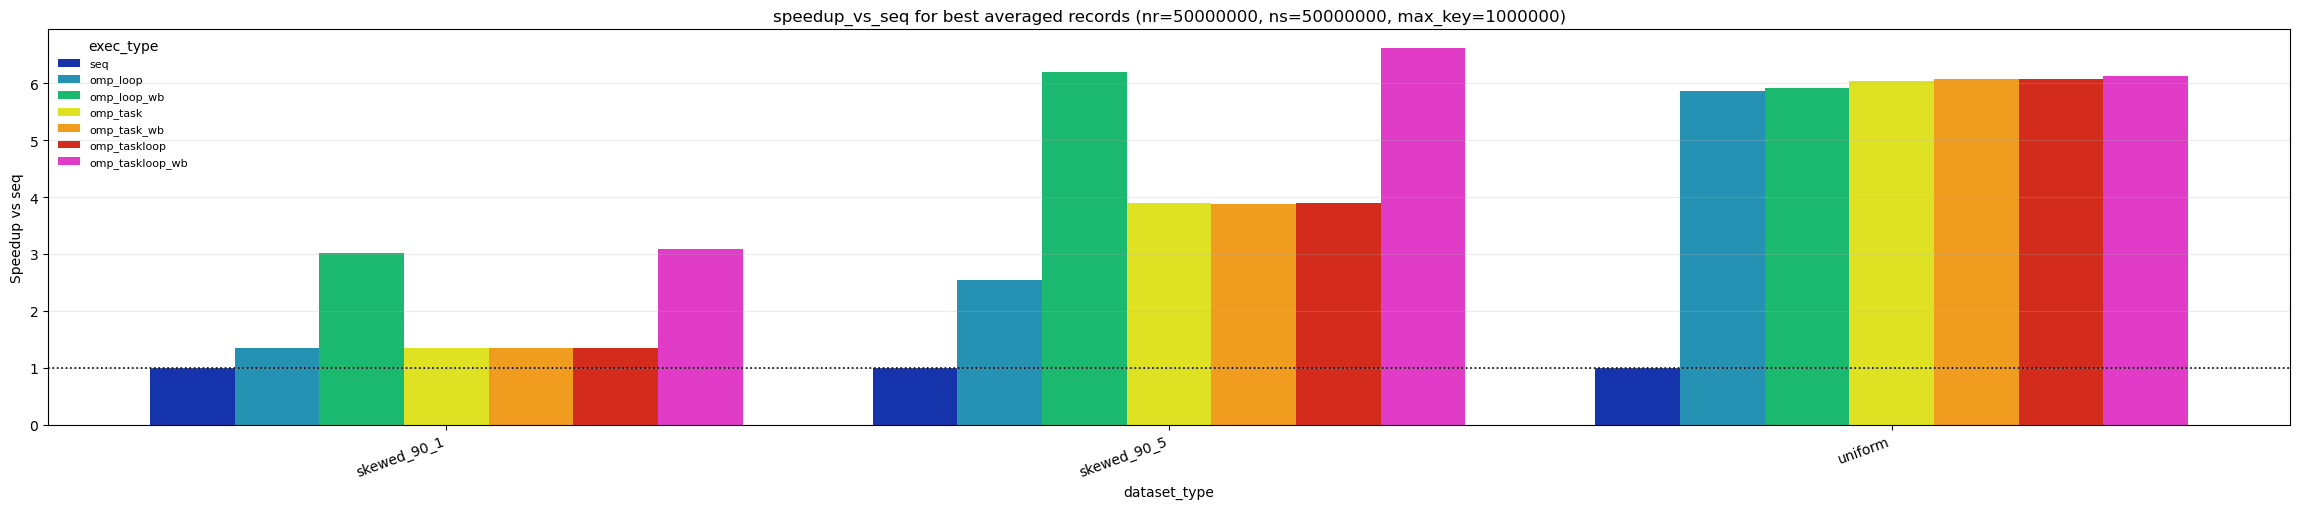

,nr,ns,max_key,dataset_type,exec_type,tot_sec,seq_tot_sec,speedup_vs_seq
0,50000000,50000000,1000000,skewed_90_1,omp_loop,2.568697,3.455040,1.345056
1,50000000,50000000,1000000,skewed_90_1,omp_loop_wb,1.144167,3.455040,3.019698
2,50000000,50000000,1000000,skewed_90_1,omp_task,2.563019,3.455040,1.348035
3,50000000,50000000,1000000,skewed_90_1,omp_task_wb,2.561850,3.455040,1.348650
4,50000000,50000000,1000000,skewed_90_1,omp_taskloop,2.565969,3.455040,1.346486
5,50000000,50000000,1000000,skewed_90_1,omp_taskloop_wb,1.117984,3.455040,3.090419
6,50000000,50000000,1000000,skewed_90_1,seq,3.455040,3.455040,1.000000
7,50000000,50000000,1000000,skewed_90_5,omp_loop,1.325910,3.361377,2.535148
8,50000000,50000000,1000000,skewed_90_5,omp_loop_wb,0.542302,3.361377,6.198349
9,50000000,50000000,1000000,skewed_90_5,omp_task,0.861789,3.361377,3.900466


In [184]:
baseline_exec_type = "seq"
baseline_columns = problem_columns + ["dataset_type"]
seq_baseline = (
    selected_best_df[selected_best_df["exec_type"] == baseline_exec_type][baseline_columns + ["tot_sec"]]
    .rename(columns={"tot_sec": "seq_tot_sec"})
)

if seq_baseline.empty:
    print("[warning] No seq selected baseline available; skipping speedup_vs_seq")
    speedup_selected_df = pd.DataFrame()
else:
    speedup_selected_df = selected_best_df.merge(seq_baseline, on=baseline_columns, how="left")
    speedup_selected_df["speedup_vs_seq"] = speedup_selected_df["seq_tot_sec"] / speedup_selected_df["tot_sec"].where(speedup_selected_df["tot_sec"] > 0)
    plot_selected_metric(speedup_selected_df, "speedup_vs_seq", "Speedup vs seq", "speedup_vs_seq", hline=1.0)

display_columns = [col for col in baseline_columns + ["exec_type", "tot_sec", "seq_tot_sec", "speedup_vs_seq"] if col in speedup_selected_df.columns]
if not speedup_selected_df.empty:
    display(speedup_selected_df[display_columns].sort_values(baseline_columns + ["exec_type"]))


[saved] img/005_selected_best_phase_breakdown_50000000_50000000_1000000.png


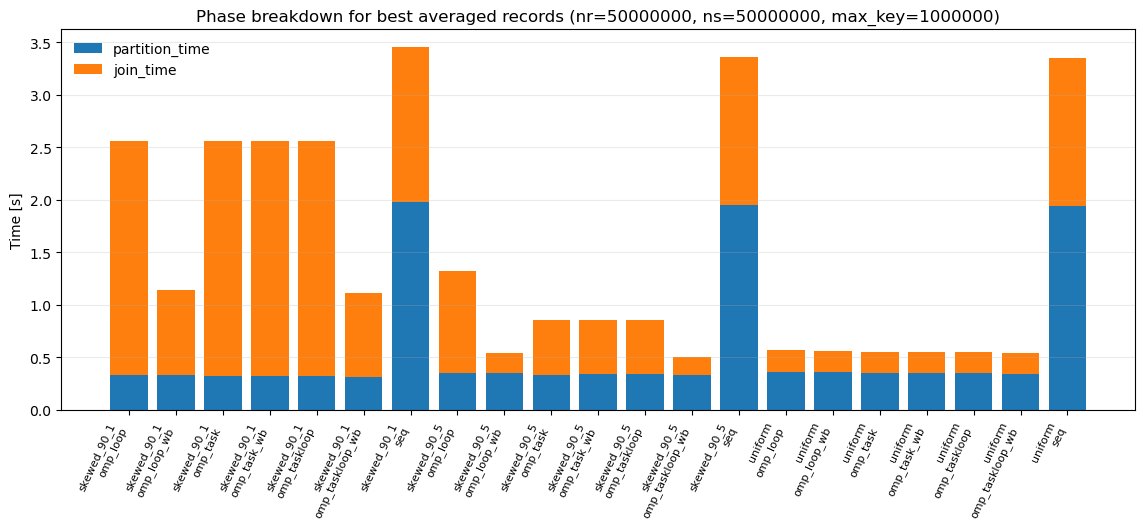

In [185]:
phase_required = set(problem_columns + ["dataset_type", "exec_type", "partition_time", "join_time"])
if phase_required.issubset(selected_best_df.columns):
    phase_df = selected_best_df.dropna(subset=["partition_time", "join_time"]).copy()
    phase_df["label"] = phase_df["dataset_type"].astype(str) + "\n" + phase_df["exec_type"].astype(str)

    for problem_key, subdf in phase_df.groupby(problem_columns, dropna=False):
        if not isinstance(problem_key, tuple):
            problem_key = (problem_key,)
        subdf = subdf.sort_values(["dataset_type", "exec_type"])
        x_positions = np.arange(len(subdf))

        fig, ax = plt.subplots(figsize=(max(10.0, 0.55 * len(subdf)), 5.4))
        ax.bar(x_positions, subdf["partition_time"], label="partition_time", color="tab:blue")
        ax.bar(x_positions, subdf["join_time"], bottom=subdf["partition_time"], label="join_time", color="tab:orange")
        ax.set_xticks(x_positions)
        ax.set_xticklabels(subdf["label"], rotation=65, ha="right", fontsize=8)
        ax.set_ylabel("Time [s]")
        ax.set_title(f"Phase breakdown for best averaged records ({problem_label(problem_key)})")
        ax.grid(axis="y", alpha=0.25)
        ax.legend(frameon=False)
        fig.tight_layout()
        show_and_save(fig, f"selected_best_phase_breakdown_{'_'.join(fmt_num(v) for v in problem_key)}")
else:
    print(f"Skipping phase breakdown: missing {sorted(phase_required - set(selected_best_df.columns))}")


# Skew Impact

[saved] img/006_selected_best_skew_penalty_vs_uniform_50000000_50000000_1000000.png


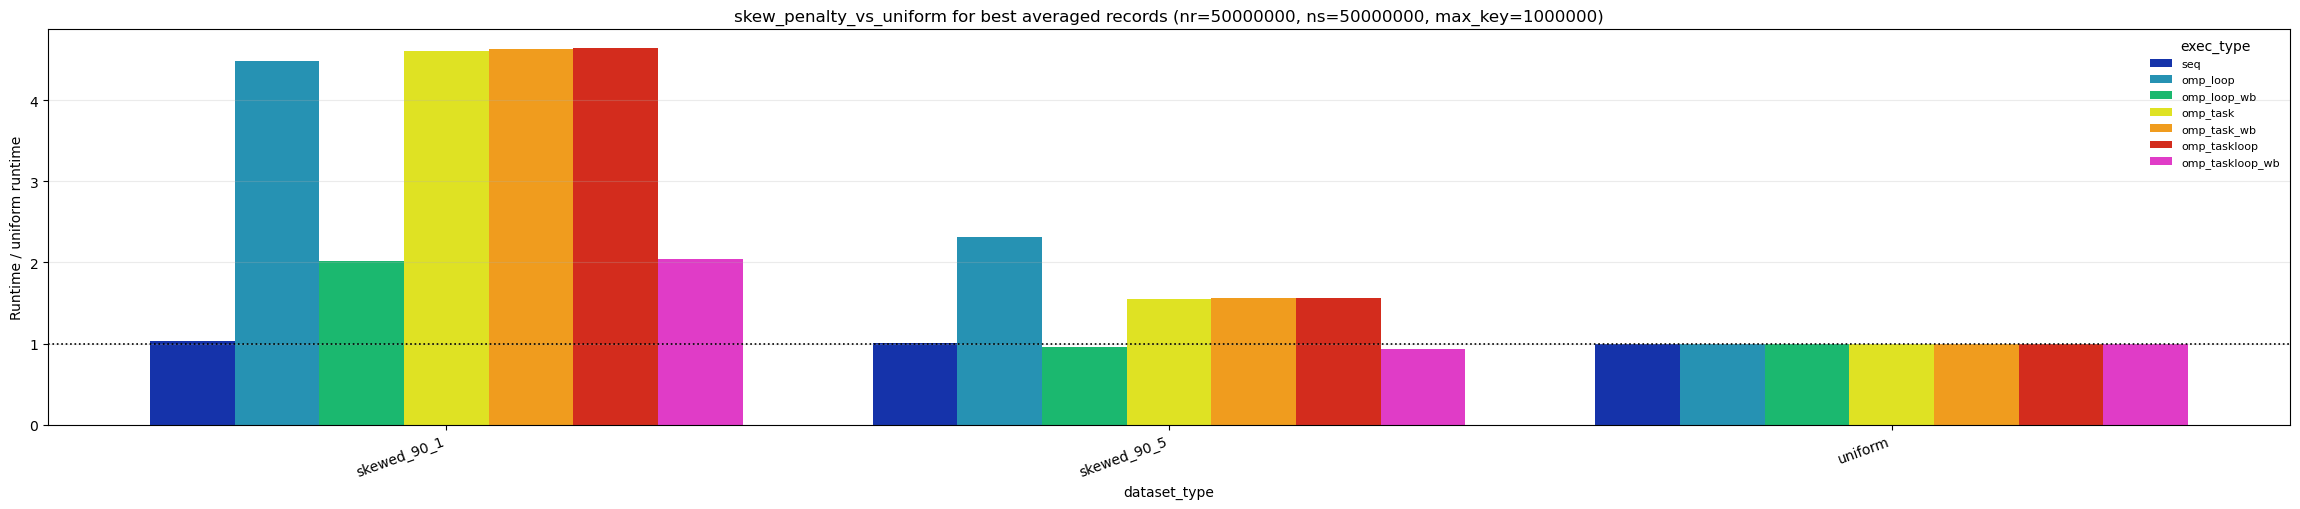

,nr,ns,max_key,dataset_type,exec_type,tot_sec,uniform_tot_sec,skew_penalty_vs_uniform
0,50000000,50000000,1000000,skewed_90_1,omp_loop,2.568697,0.572243,4.488820
7,50000000,50000000,1000000,skewed_90_5,omp_loop,1.325910,0.572243,2.317039
14,50000000,50000000,1000000,uniform,omp_loop,0.572243,0.572243,1.000000
1,50000000,50000000,1000000,skewed_90_1,omp_loop_wb,1.144167,0.567597,2.015811
8,50000000,50000000,1000000,skewed_90_5,omp_loop_wb,0.542302,0.567597,0.955436
15,50000000,50000000,1000000,uniform,omp_loop_wb,0.567597,0.567597,1.000000
2,50000000,50000000,1000000,skewed_90_1,omp_task,2.563019,0.555685,4.612356
9,50000000,50000000,1000000,skewed_90_5,omp_task,0.861789,0.555685,1.550857
16,50000000,50000000,1000000,uniform,omp_task,0.555685,0.555685,1.000000
3,50000000,50000000,1000000,skewed_90_1,omp_task_wb,2.561850,0.553611,4.627524


In [186]:
skew_key_columns = problem_columns + ["exec_type"]
uniform_rows = selected_best_df[selected_best_df["dataset_type"] == "uniform"][skew_key_columns + ["tot_sec"]]

if uniform_rows.empty:
    print("[warning] No uniform selected records available; skipping skew impact comparison")
    skew_impact_df = pd.DataFrame()
else:
    uniform_rows = uniform_rows.rename(columns={"tot_sec": "uniform_tot_sec"})
    skew_impact_df = selected_best_df.merge(uniform_rows, on=skew_key_columns, how="left")
    skew_impact_df["skew_penalty_vs_uniform"] = skew_impact_df["tot_sec"] / skew_impact_df["uniform_tot_sec"].where(skew_impact_df["uniform_tot_sec"] > 0)
    plot_selected_metric(skew_impact_df, "skew_penalty_vs_uniform", "Runtime / uniform runtime", "skew_penalty_vs_uniform", hline=1.0)

if not skew_impact_df.empty:
    display(skew_impact_df[[col for col in problem_columns + ["dataset_type", "exec_type", "tot_sec", "uniform_tot_sec", "skew_penalty_vs_uniform"] if col in skew_impact_df.columns]].sort_values(problem_columns + ["exec_type", "dataset_type"]))


# Scaling Data Helpers

In [187]:
def existing_paths(paths):
    return [path for path in paths if path.exists()]


def load_named_csv_sources(source_specs):
    frames = []
    loaded = []
    missing = []
    for spec in source_specs:
        paths = existing_paths(spec["paths"])
        if not paths:
            missing.append(spec["name"])
            continue
        csv_path = paths[0]
        frame = normalize_frame(pd.read_csv(csv_path))
        frame["source"] = spec["name"]
        if "exec_type" not in frame.columns or frame["exec_type"].isna().all():
            frame["exec_type"] = spec.get("exec_type", csv_path.stem.replace("hashjoin_", "", 1))
        if "dataset_type" not in frame.columns:
            frame["dataset_type"] = spec.get("dataset_type", "uniform")
        frames.append(frame)
        loaded.append((spec["name"], csv_path))

    if loaded:
        print("Loaded scaling sources:")
        for name, csv_path in loaded:
            print(f"  - {name}: {csv_path}")
    if missing:
        print(f"[info] Missing scaling sources: {missing}")

    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True, sort=False)


def average_scaling_df(raw_scaling_df, extra_group_columns):
    if raw_scaling_df.empty:
        return raw_scaling_df

    group_columns = [col for col in extra_group_columns if col in raw_scaling_df.columns]
    avg_columns = [
        col for col in raw_scaling_df.columns
        if col not in group_columns and pd.api.types.is_numeric_dtype(raw_scaling_df[col])
    ]
    return (
        raw_scaling_df.groupby(group_columns, as_index=False, dropna=False)
        .agg(**{col: (col, "mean") for col in avg_columns}, n_runs=("tot_sec", "size"))
        .sort_values(group_columns)
        .reset_index(drop=True)
    )


def prepare_scaling_plot_df(raw_scaling_df, scaling_kind):
    if raw_scaling_df.empty:
        return pd.DataFrame(), None

    scaling_df = raw_scaling_df.copy()
    if "partition_threads" in scaling_df.columns and "join_threads" in scaling_df.columns:
        scaling_df = scaling_df[scaling_df["partition_threads"] == scaling_df["join_threads"]].copy()
        threads_col = "partition_threads"
    elif "partition_threads" in scaling_df.columns:
        threads_col = "partition_threads"
    elif "join_threads" in scaling_df.columns:
        threads_col = "join_threads"
    else:
        raise KeyError(f"{scaling_kind} scaling data must contain partition_threads or join_threads")

    if scaling_df.empty:
        print(f"[warning] No {scaling_kind} rows after requiring partition_threads == join_threads")
        return pd.DataFrame(), threads_col

    scaling_df["perf"] = np.nan
    if "total_throughput" in scaling_df.columns:
        scaling_df["perf"] = scaling_df["total_throughput"]
    if "tot_sec" in scaling_df.columns:
        scaling_df["perf"] = scaling_df["perf"].fillna(1.0 / scaling_df["tot_sec"].where(scaling_df["tot_sec"] > 0))

    scaling_df = scaling_df.dropna(subset=[threads_col, "perf"]).copy()
    if scaling_df.empty:
        print(f"[warning] No valid {scaling_kind} scaling performance rows")
        return pd.DataFrame(), threads_col

    group_columns = ["source", "exec_type", "dataset_type", "nr", "ns", "max_key", threads_col]
    scaling_avg_df = average_scaling_df(scaling_df, group_columns)
    return scaling_avg_df, threads_col


def plot_scaling_bars(plot_df, threads_col, metric_col, ylabel, title, filename_prefix, group_by_n=True, series_columns=None):
    if plot_df.empty:
        print(f"Skipping {title}: no rows")
        return

    group_columns = ["nr", "ns", "max_key"] if group_by_n else []
    grouped = plot_df.groupby(group_columns, dropna=False) if group_columns else [((), plot_df)]

    for problem_key, subdf in grouped:
        if not isinstance(problem_key, tuple):
            problem_key = (problem_key,)
        thread_values = ordered_values(subdf[threads_col])
        if series_columns is None:
            series_columns = ["source", "exec_type", "dataset_type"]
        series_columns = [col for col in series_columns if col in subdf.columns]
        series_df = subdf[series_columns].drop_duplicates().sort_values(series_columns)
        series_records = series_df.to_dict("records")
        if not thread_values or not series_records:
            continue

        x_positions = np.arange(len(thread_values))
        bar_width = 0.82 / max(len(series_records), 1)
        fig, ax = plt.subplots(figsize=(max(9.5, 0.8 * len(thread_values) * len(series_records)), 5.4))

        for idx, series in enumerate(series_records):
            mask = np.ones(len(subdf), dtype=bool)
            for col, value in series.items():
                mask &= subdf[col].eq(value).to_numpy()
            series_sub = subdf[mask]
            values = series_sub.set_index(threads_col)[metric_col].to_dict()
            heights = [float(values.get(thread, np.nan)) for thread in thread_values]
            offsets = x_positions + (idx - (len(series_records) - 1) / 2.0) * bar_width
            label_parts = []
            for col in series_columns:
                value = series[col]
                if col in {"nr", "ns", "max_key"}:
                    label_parts.append(f"{col}={fmt_num(value)}")
                else:
                    label_parts.append(str(value))
            label = " / ".join(label_parts)
            color = color_map.get(series.get("exec_type"), None)
            ax.bar(offsets, heights, width=bar_width, label=label, color=color, alpha=0.9)

        ax.axhline(1.0, color="black", linestyle=":", linewidth=1.2)
        ax.set_xticks(x_positions)
        ax.set_xticklabels([fmt_num(t) for t in thread_values])
        ax.set_xlabel("Number of threads (partition = join)")
        ax.set_ylabel(ylabel)
        title_suffix = f" ({problem_label(problem_key)})" if group_columns else ""
        ax.set_title(title + title_suffix)
        ax.grid(axis="y", alpha=0.25)
        ax.legend(fontsize=7, frameon=False)
        fig.tight_layout()
        suffix = "_".join(fmt_num(v) for v in problem_key) if group_columns else "all"
        show_and_save(fig, f"{filename_prefix}_{suffix}")


# Strong Scaling Comparison

Loaded scaling sources:
  - module2_cpp_threads: old_results/hashjoin_par_pj_wb_map.csv
[info] Missing scaling sources: ['module3_openmp']
[saved] img/007_strong_scaling_speedup_50000000_50000000_1000000.png


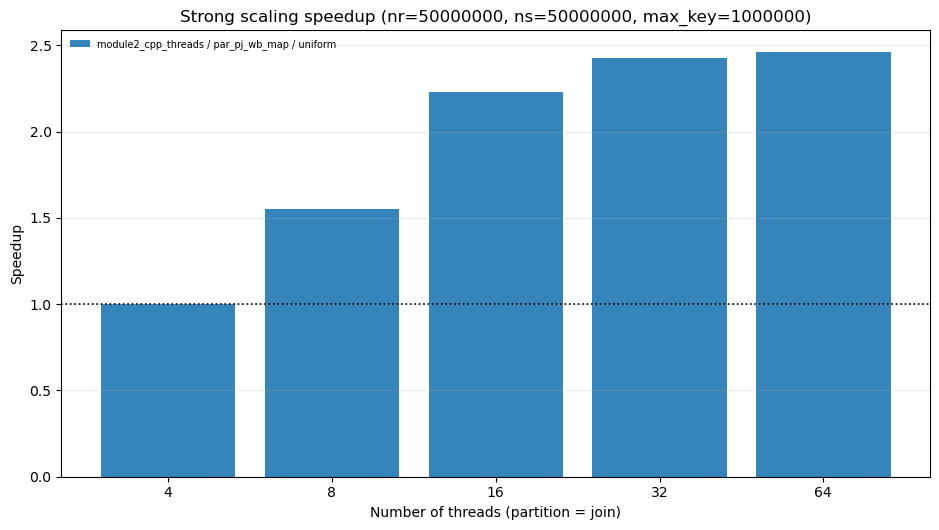

[saved] img/008_strong_scaling_efficiency_50000000_50000000_1000000.png


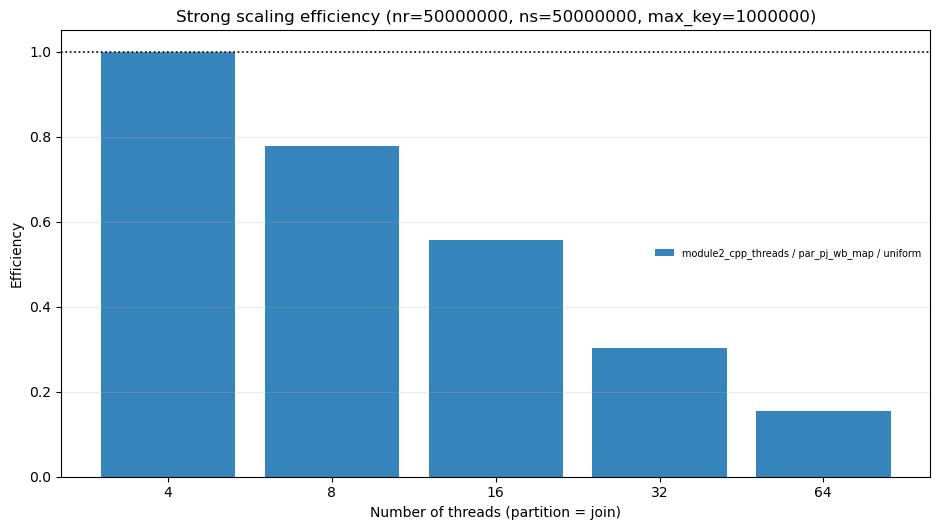

,source,exec_type,dataset_type,nr,ns,max_key,partition_threads,checksum1,checksum2,join_count,...,time_sec,total_throughput,tot_sec,perf,n_runs,baseline_thread,baseline_perf,baseline_threads,speedup,parallel_efficiency
0,module2_cpp_threads,par_pj_wb_map,uniform,50000000,50000000,1000000,4,6.185417e+18,1.693109e+19,2.499986e+09,...,1.355512,7.378457e+07,1.355512,7.378457e+07,5,4,7.378457e+07,4,1.000000,1.000000
1,module2_cpp_threads,par_pj_wb_map,uniform,50000000,50000000,1000000,8,6.185417e+18,1.693109e+19,2.499986e+09,...,0.872385,1.146291e+08,0.872385,1.146291e+08,5,4,7.378457e+07,4,1.553565,0.776783
2,module2_cpp_threads,par_pj_wb_map,uniform,50000000,50000000,1000000,16,6.185417e+18,1.693109e+19,2.499986e+09,...,0.610391,1.643181e+08,0.610391,1.643181e+08,5,4,7.378457e+07,4,2.226998,0.556749
3,module2_cpp_threads,par_pj_wb_map,uniform,50000000,50000000,1000000,32,6.185417e+18,1.693109e+19,2.499986e+09,...,0.559303,1.788460e+08,0.559303,1.788460e+08,5,4,7.378457e+07,4,2.423894,0.302987
4,module2_cpp_threads,par_pj_wb_map,uniform,50000000,50000000,1000000,64,6.185417e+18,1.693109e+19,2.499986e+09,...,0.550269,1.817333e+08,0.550269,1.817333e+08,5,4,7.378457e+07,4,2.463026,0.153939


In [188]:
old_results_dir = first_existing_dir(OLD_RESULTS_CANDIDATES)
strong_sources = []
if old_results_dir is not None:
    strong_sources.append({
        "name": "module2_cpp_threads",
        "paths": [old_results_dir / "hashjoin_par_pj_wb_map.csv", old_results_dir / "hashjoin_pj_wb_map.csv"],
        "exec_type": "par_pj_wb_map",
        "dataset_type": "uniform",
    })
strong_sources.append({
    "name": "module3_openmp",
    "paths": [RESULTS_DIR / "strong_scaling.csv"],
    "dataset_type": "uniform",
})

strong_raw_df = load_named_csv_sources(strong_sources)
strong_scaling_df, strong_threads_col = prepare_scaling_plot_df(strong_raw_df, "strong")

if not strong_scaling_df.empty:
    strong_key_cols = ["source", "exec_type", "dataset_type", "nr", "ns", "max_key"]
    strong_scaling_df["baseline_thread"] = strong_scaling_df.groupby(strong_key_cols)[strong_threads_col].transform("min")
    baseline_perf = (
        strong_scaling_df[strong_scaling_df[strong_threads_col] == strong_scaling_df["baseline_thread"]]
        [strong_key_cols + ["perf", strong_threads_col]]
        .rename(columns={"perf": "baseline_perf", strong_threads_col: "baseline_threads"})
    )
    strong_scaling_df = strong_scaling_df.merge(baseline_perf, on=strong_key_cols, how="left")
    strong_scaling_df = strong_scaling_df[strong_scaling_df["baseline_perf"] > 0].copy()
    strong_scaling_df["speedup"] = strong_scaling_df["perf"] / strong_scaling_df["baseline_perf"]
    strong_scaling_df["parallel_efficiency"] = strong_scaling_df["speedup"] / (strong_scaling_df[strong_threads_col] / strong_scaling_df["baseline_threads"])

    plot_scaling_bars(strong_scaling_df, strong_threads_col, "speedup", "Speedup", "Strong scaling speedup", "strong_scaling_speedup")
    plot_scaling_bars(strong_scaling_df, strong_threads_col, "parallel_efficiency", "Efficiency", "Strong scaling efficiency", "strong_scaling_efficiency")
    display(strong_scaling_df.sort_values(["source", "exec_type", "dataset_type", "nr", strong_threads_col]).reset_index(drop=True))
else:
    print("No strong-scaling comparison available yet.")


# Weak Scaling Comparison

Loaded scaling sources:
  - module2_cpp_threads: old_results/weak_scaling.csv
[info] Missing scaling sources: ['module3_openmp']
[saved] img/009_weak_scaling_speedup_by_N_all.png


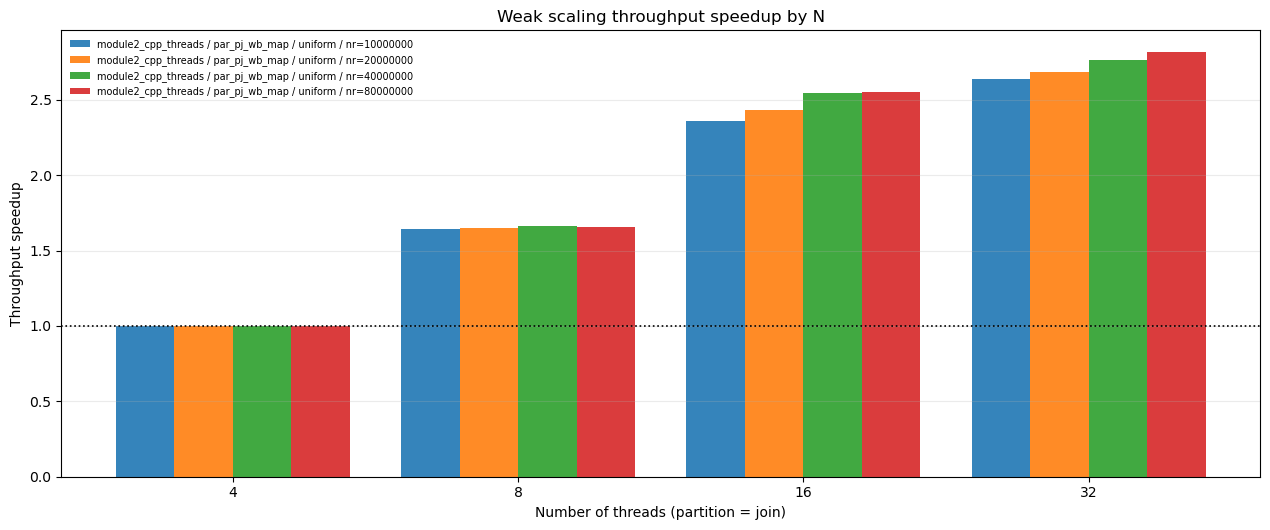

[saved] img/010_weak_scaling_efficiency_by_N_all.png


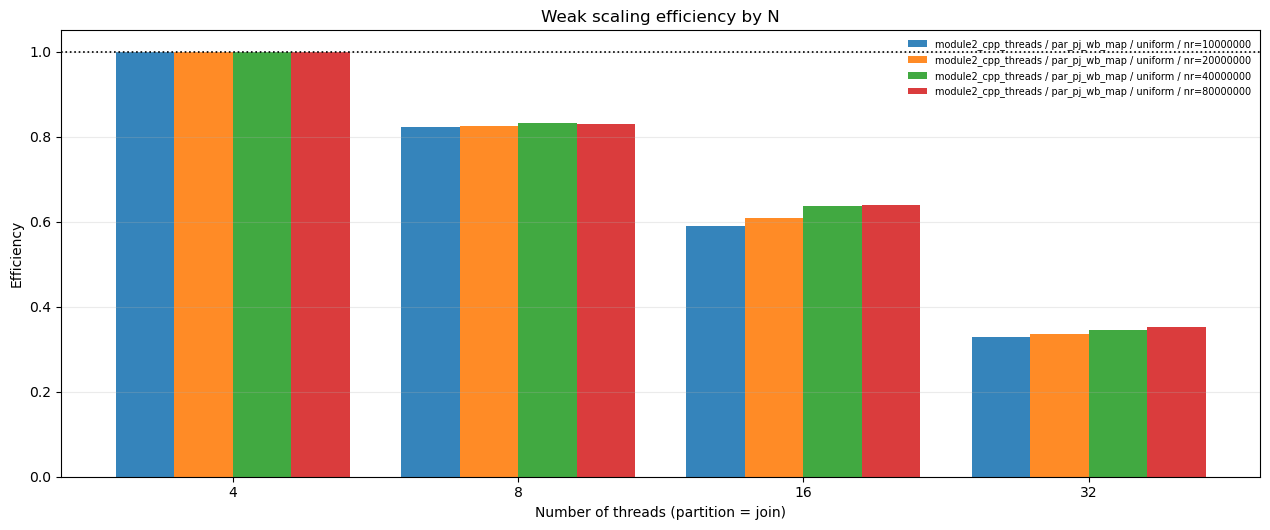

,source,exec_type,dataset_type,nr,ns,max_key,partition_threads,checksum1,checksum2,join_count,...,time_sec,total_throughput,tot_sec,perf,n_runs,baseline_thread,baseline_perf,baseline_threads,speedup,weak_efficiency
0,module2_cpp_threads,par_pj_wb_map,uniform,10000000,10000000,1000000,4,7.970473e+18,1.546552e+19,9.999480e+07,...,0.319345,6.263069e+07,0.319345,6.263069e+07,5,4,6.263069e+07,4,1.000000,1.000000
1,module2_cpp_threads,par_pj_wb_map,uniform,10000000,10000000,1000000,8,7.970473e+18,1.546552e+19,9.999480e+07,...,0.193986,1.031117e+08,0.193986,1.031117e+08,5,4,6.263069e+07,4,1.646344,0.823172
2,module2_cpp_threads,par_pj_wb_map,uniform,10000000,10000000,1000000,16,7.970473e+18,1.546552e+19,9.999480e+07,...,0.136216,1.477446e+08,0.136216,1.477446e+08,5,4,6.263069e+07,4,2.358981,0.589745
3,module2_cpp_threads,par_pj_wb_map,uniform,10000000,10000000,1000000,32,7.970473e+18,1.546552e+19,9.999480e+07,...,0.121052,1.652264e+08,0.121052,1.652264e+08,5,4,6.263069e+07,4,2.638107,0.329763
4,module2_cpp_threads,par_pj_wb_map,uniform,20000000,20000000,1000000,4,9.484501e+18,3.838711e+17,4.000185e+08,...,0.607117,6.588559e+07,0.607117,6.588559e+07,5,4,6.588559e+07,4,1.000000,1.000000
5,module2_cpp_threads,par_pj_wb_map,uniform,20000000,20000000,1000000,8,9.484501e+18,3.838711e+17,4.000185e+08,...,0.367459,1.088563e+08,0.367459,1.088563e+08,5,4,6.588559e+07,4,1.652201,0.826101
6,module2_cpp_threads,par_pj_wb_map,uniform,20000000,20000000,1000000,16,9.484501e+18,3.838711e+17,4.000185e+08,...,0.250049,1.603368e+08,0.250049,1.603368e+08,5,4,6.588559e+07,4,2.433564,0.608391
7,module2_cpp_threads,par_pj_wb_map,uniform,20000000,20000000,1000000,32,9.484501e+18,3.838711e+17,4.000185e+08,...,0.226457,1.766728e+08,0.226457,1.766728e+08,5,4,6.588559e+07,4,2.681508,0.335189
8,module2_cpp_threads,par_pj_wb_map,uniform,40000000,40000000,1000000,4,3.575568e+18,7.674071e+18,1.599983e+09,...,1.242003,6.441453e+07,1.242003,6.441453e+07,5,4,6.441453e+07,4,1.000000,1.000000
9,module2_cpp_threads,par_pj_wb_map,uniform,40000000,40000000,1000000,8,3.575568e+18,7.674071e+18,1.599983e+09,...,0.747165,1.070715e+08,0.747165,1.070715e+08,5,4,6.441453e+07,4,1.662226,0.831113


In [189]:
weak_sources = []
if old_results_dir is not None:
    weak_sources.append({
        "name": "module2_cpp_threads",
        "paths": [old_results_dir / "weak_scaling.csv"],
        "exec_type": "par_pj_wb_map",
        "dataset_type": "uniform",
    })
weak_sources.append({
    "name": "module3_openmp",
    "paths": [RESULTS_DIR / "weak_scaling.csv"],
    "dataset_type": "uniform",
})

weak_raw_df = load_named_csv_sources(weak_sources)
weak_scaling_df, weak_threads_col = prepare_scaling_plot_df(weak_raw_df, "weak")

if not weak_scaling_df.empty:
    # Match the old_statistics treatment: each N is its own series, normalized
    # to the smallest available thread count for that same source/exec/dataset/N.
    weak_key_cols = ["source", "exec_type", "dataset_type", "nr", "ns", "max_key"]
    weak_scaling_df["baseline_thread"] = weak_scaling_df.groupby(weak_key_cols)[weak_threads_col].transform("min")
    baseline_perf = (
        weak_scaling_df[weak_scaling_df[weak_threads_col] == weak_scaling_df["baseline_thread"]]
        [weak_key_cols + ["perf", weak_threads_col]]
        .rename(columns={"perf": "baseline_perf", weak_threads_col: "baseline_threads"})
    )
    weak_scaling_df = weak_scaling_df.merge(baseline_perf, on=weak_key_cols, how="left")
    weak_scaling_df = weak_scaling_df[weak_scaling_df["baseline_perf"] > 0].copy()
    weak_scaling_df["speedup"] = weak_scaling_df["perf"] / weak_scaling_df["baseline_perf"]
    weak_scaling_df["weak_efficiency"] = weak_scaling_df["speedup"] / (weak_scaling_df[weak_threads_col] / weak_scaling_df["baseline_threads"])

    weak_series_columns = ["source", "exec_type", "dataset_type", "nr"]
    plot_scaling_bars(
        weak_scaling_df,
        weak_threads_col,
        "speedup",
        "Throughput speedup",
        "Weak scaling throughput speedup by N",
        "weak_scaling_speedup_by_N",
        group_by_n=False,
        series_columns=weak_series_columns,
    )
    plot_scaling_bars(
        weak_scaling_df,
        weak_threads_col,
        "weak_efficiency",
        "Efficiency",
        "Weak scaling efficiency by N",
        "weak_scaling_efficiency_by_N",
        group_by_n=False,
        series_columns=weak_series_columns,
    )
    display(weak_scaling_df.sort_values(["source", "exec_type", "dataset_type", "nr", weak_threads_col]).reset_index(drop=True))
else:
    print("No weak-scaling comparison available yet.")


# Interpretation Tables

In [190]:
interpretation_columns = [
    col for col in problem_columns + [
        "dataset_type", "exec_type", "tot_sec", "partition_time", "join_time",
        "total_throughput", "partition_threads", "join_threads", "partition_schedule",
        "join_schedule", "partition_block_size", "partition_task_grain",
        "join_task_grain", "offset_task_grain",
    ] if col in selected_best_df.columns
]

best_by_dataset = selected_best_df.sort_values(problem_columns + ["dataset_type", "tot_sec"]).groupby(problem_columns + ["dataset_type"], dropna=False).head(1)
print("Fastest implementation per dataset_type:")
display(best_by_dataset[interpretation_columns].reset_index(drop=True))

if not speedup_selected_df.empty and "speedup_vs_seq" in speedup_selected_df.columns:
    print("Best selected records ranked by speedup vs sequential baseline:")
    display(speedup_selected_df.sort_values("speedup_vs_seq", ascending=False)[[col for col in interpretation_columns + ["speedup_vs_seq"] if col in speedup_selected_df.columns]].reset_index(drop=True))


Fastest implementation per dataset_type:


,nr,ns,max_key,dataset_type,exec_type,tot_sec,partition_time,join_time,total_throughput,partition_threads,join_threads,partition_schedule,join_schedule,partition_block_size,partition_task_grain,join_task_grain,offset_task_grain
0,50000000,50000000,1000000,skewed_90_1,omp_taskloop_wb,1.117984,0.318516,0.796259,8.946668e+07,64,32,auto,auto,32768,2.0,4.0,4.0
1,50000000,50000000,1000000,skewed_90_5,omp_taskloop_wb,0.508043,0.336886,0.167900,1.968550e+08,64,32,auto,auto,32768,4.0,4.0,2.0
2,50000000,50000000,1000000,uniform,omp_taskloop_wb,0.547891,0.347257,0.197457,1.825359e+08,64,32,auto,auto,32768,2.0,8.0,4.0


Best selected records ranked by speedup vs sequential baseline:


,nr,ns,max_key,dataset_type,exec_type,tot_sec,partition_time,join_time,total_throughput,partition_threads,join_threads,partition_schedule,join_schedule,partition_block_size,partition_task_grain,join_task_grain,offset_task_grain,speedup_vs_seq
0,50000000,50000000,1000000,skewed_90_5,omp_taskloop_wb,0.508043,0.336886,0.167900,1.968550e+08,64,32,auto,auto,32768,4.0,4.0,2.0,6.616329
1,50000000,50000000,1000000,skewed_90_5,omp_loop_wb,0.542302,0.354974,0.184001,1.847429e+08,32,32,guided,guided,32768,NaN,NaN,NaN,6.198349
2,50000000,50000000,1000000,uniform,omp_taskloop_wb,0.547891,0.347257,0.197457,1.825359e+08,64,32,auto,auto,32768,2.0,8.0,4.0,6.130256
3,50000000,50000000,1000000,uniform,omp_taskloop,0.552835,0.349482,0.200110,1.809118e+08,64,32,auto,auto,32768,2.0,8.0,2.0,6.075436
4,50000000,50000000,1000000,uniform,omp_task_wb,0.553611,0.349451,0.200741,1.806579e+08,64,32,auto,auto,32768,2.0,4.0,4.0,6.066918
5,50000000,50000000,1000000,uniform,omp_task,0.555685,0.349108,0.203093,1.799686e+08,64,32,auto,auto,32768,2.0,8.0,2.0,6.044274
6,50000000,50000000,1000000,uniform,omp_loop_wb,0.567597,0.363186,0.201050,1.761927e+08,32,32,guided,guided,32768,NaN,NaN,NaN,5.917433
7,50000000,50000000,1000000,uniform,omp_loop,0.572243,0.363569,0.205276,1.747551e+08,32,32,guided,guided,32768,NaN,NaN,NaN,5.869384
8,50000000,50000000,1000000,skewed_90_5,omp_task,0.861789,0.334793,0.523728,1.160622e+08,64,32,auto,auto,32768,4.0,4.0,4.0,3.900466
9,50000000,50000000,1000000,skewed_90_5,omp_taskloop,0.862132,0.343024,0.515998,1.160190e+08,64,32,auto,auto,32768,4.0,4.0,4.0,3.898914
